In [9]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [2]:
X = pd.read_csv('../../data/processed/normalized_best_features.csv', index_col=0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [3]:
df_engineered = pd.read_csv('../../data/processed/normalized_best_features.csv')
df_meta = pd.read_csv('../../data/processed/meta_best.csv')
df_with_clusters = df_meta.join(df_engineered)

In [4]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

gmm_final = GaussianMixture(
    n_components=4,
    covariance_type="full",
    random_state=42,
    n_init=10
)

cluster_labels = gmm_final.fit_predict(X_pca)
cluster_probs = gmm_final.predict_proba(X_pca)
df_with_clusters["role_cluster"] = cluster_labels

for k in range(gmm_final.n_components):
    df_with_clusters[f"cluster_{k}_prob"] = cluster_probs[:, k]

In [5]:
for c in sorted(df_with_clusters["role_cluster"].unique()):
    print(f"\n=== Cluster {c}: Top 10 by CA ===")
    display(
        df_with_clusters[df_with_clusters["role_cluster"] == c]
        [["Name","Club","CA","PA"]]
        .sort_values(by="CA", ascending=False)
        .head(10)
    )


=== Cluster 0: Top 10 by CA ===


,Name,Club,CA,PA
0,Harry Kane,FC Bayern,184,185
2,Joshua Kimmich,FC Bayern,174,183
5,Luka Modrić,R. Madrid,171,180
14,İlkay Gündoğan,Barcelona,167,167
15,Frenkie de Jong,Barcelona,165,181
27,Bruno Guimarães,Newcastle,165,170
10,Thiago,Liverpool,163,173
28,Trent Alexander-Arnold,Liverpool,162,174
20,David Alaba,R. Madrid,159,174
84,Alexis Mac Allister,Liverpool,158,165



=== Cluster 1: Top 10 by CA ===


,Name,Club,CA,PA
6,Declan Rice,Arsenal,176,182
8,Eduardo Camavinga,R. Madrid,170,180
31,Reece James,Chelsea,161,170
16,Casemiro,Man UFC,157,170
18,Leon Goretzka,FC Bayern,157,170
24,Aurélien Tchouameni,R. Madrid,157,177
136,Yves Bissouma,Tottenham,157,165
22,Adrien Rabiot,Juventus,156,159
82,Benjamin White,Arsenal,155,162
77,João Palhinha,Fulham,155,164



=== Cluster 2: Top 10 by CA ===


,Name,Club,CA,PA
9,Martin Ødegaard,Arsenal,173,180
7,Bruno Fernandes,Man UFC,171,174
3,Leroy Sané,FC Bayern,169,172
13,Pedri,Barcelona,162,175
25,Christopher Nkunku,Chelsea,162,172
21,Hakan Çalhanoğlu,Inter,160,160
45,Dejan Kulusevski,Tottenham,160,171
49,James Maddison,Tottenham,159,163
35,Marco Asensio,Paris SG,159,163
12,Jamal Musiala,FC Bayern,158,185



=== Cluster 3: Top 10 by CA ===


,Name,Club,CA,PA
1,Jude Bellingham,R. Madrid,177,188
11,Federico Valverde,R. Madrid,168,175
4,Nicolò Barella,Inter,161,169
115,Moisés Caicedo,Chelsea,156,185
34,Mason Mount,Man UFC,156,170
17,Thomas Müller,FC Bayern,155,174
37,Gavi,Barcelona,154,187
68,André-Franck Zambo Anguissa,Parthenope,153,162
133,John McGinn,Aston Villa,153,155
92,James Ward-Prowse,West Ham,150,155


In [6]:
def summarize_clusters(df_k, feature_cols):
    print("\n=== Cluster sizes ===")
    print(df_k["cluster"].value_counts().sort_index())
    
    print("\n=== Age / CA / PA by cluster ===")
    print(df_k.groupby("cluster")[["Age","CA","PA"]].mean().round(2))
summarize_clusters(df_with_clusters.rename(columns={"role_cluster":"cluster"}), X.columns.tolist())


=== Cluster sizes ===
cluster
0    127
1    225
2    200
3    131
Name: count, dtype: int64

=== Age / CA / PA by cluster ===
           Age      CA      PA
cluster                       
0        26.13  138.29  151.72
1        26.57  135.13  146.29
2        24.94  137.00  151.40
3        24.48  133.19  147.55


In [7]:
def cluster_attribute_profiles(df_k, feature_cols):
    scaler_attr = StandardScaler()
    Z = scaler_attr.fit_transform(df_k[feature_cols].values)
    df_z = pd.DataFrame(Z, columns=feature_cols, index=df_k.index)
    df_z["cluster"] = df_k["cluster"].values

    cluster_means = df_z.groupby("cluster")[feature_cols].mean().round(3)
    return cluster_means

def print_top_attributes_per_cluster(cluster_means, top_n=8):
    for c in cluster_means.index:
        print(f"\n=== Cluster {c}: top {top_n} attributes (z-score) ===")
        s = cluster_means.loc[c].sort_values(ascending=False)
        print(s.head(top_n))
        print("\n--- lowest attributes ---")
        print(s.tail(top_n))

cluster_means = cluster_attribute_profiles(
    df_with_clusters.rename(columns={"role_cluster":"cluster"}),
    X.columns.tolist()
)
print_top_attributes_per_cluster(cluster_means, top_n=8)


=== Cluster 0: top 8 attributes (z-score) ===
Pas    0.958
Dec    0.747
Cmp    0.742
Vis    0.602
Fir    0.579
Tec    0.575
Ant    0.400
Pos    0.393
Name: 0, dtype: float64

--- lowest attributes ---
L Th    -0.303
Det     -0.325
Agi     -0.351
Agg     -0.354
Wor     -0.359
Bra     -0.368
Nat.1   -0.401
Pac     -0.656
Name: 0, dtype: float64

=== Cluster 1: top 8 attributes (z-score) ===
Mar    0.938
Tck    0.857
Bra    0.777
Hea    0.774
Pos    0.760
Str    0.755
Jum    0.668
Agg    0.566
Name: 1, dtype: float64

--- lowest attributes ---
Cro   -0.717
Dri   -0.786
Fre   -0.798
Vis   -0.816
Fir   -0.843
Cor   -0.856
Fla   -0.896
Tec   -0.946
Name: 1, dtype: float64

=== Cluster 2: top 8 attributes (z-score) ===
Fla    0.945
Dri    0.907
Fre    0.880
Cor    0.873
Tec    0.814
Fin    0.767
Cro    0.761
Fir    0.738
Name: 2, dtype: float64

--- lowest attributes ---
Sta   -0.617
Wor   -0.648
Str   -0.704
Tea   -0.709
Bra   -0.796
Mar   -0.957
Pos   -1.045
Tck   -1.049
Name: 2, dtype: fl

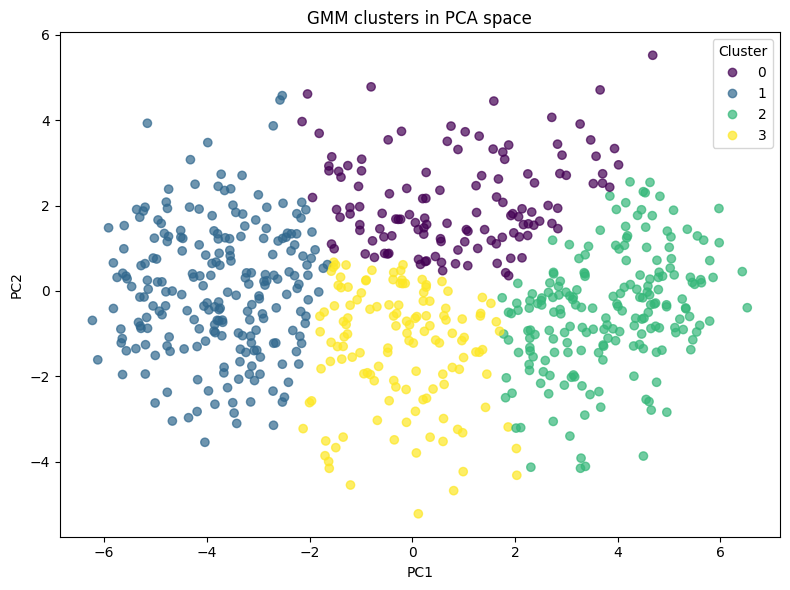

In [8]:
def plot_pca_scatter(X_pca, df_k):
    plt.figure(figsize=(8,6))
    scatter = plt.scatter(
        X_pca[:,0],
        X_pca[:,1],
        c=df_k["cluster"],
        alpha=0.7
    )
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("GMM clusters in PCA space")
    plt.legend(*scatter.legend_elements(), title="Cluster")
    plt.tight_layout()
    plt.show()
plot_pca_scatter(X_pca, df_with_clusters.rename(columns={"role_cluster":"cluster"}))

In [10]:
radar_attrs = [
    "Pas",   # passing
    "Tec",   # technique
    "Vis",   # vision
    "Dri",   # dribbling
    "Fir",   # first touch
    
    "Tck",   # tackling
    "Mar",   # marking
    "Pos",   # positioning
    "Agg",   # aggression
    "Bra",   # bravery
    
    "Sta",   # stamina
    "Pac",   # pace
    "Wor",   # work rate
    "Ant",   # anticipation
    "Dec",   # decisions
]

def plot_radar(cluster_means, radar_attrs, cluster_id):
    values = cluster_means.loc[cluster_id, radar_attrs].values
    labels = radar_attrs


    num_vars = len(labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False)
    values = np.concatenate((values, [values[0]]))
    angles = np.concatenate((angles, [angles[0]]))

    fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))
    
    ax.plot(angles, values, linewidth=2)
    ax.fill(angles, values, alpha=0.25)
    colors = ["#FF6B6B", "#4ECDC4", "#1A535C", "#FFE66D", "#FF9F1C"]
    color = colors[cluster_id % len(colors)]
    
    ax.fill(angles, values, color=color, alpha=0.25)
    ax.plot(angles, values, color=color, linewidth=2)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_yticklabels([])

    plt.title(f"Cluster {cluster_id} — Role Profile", size=14, pad=20)
    plt.show()

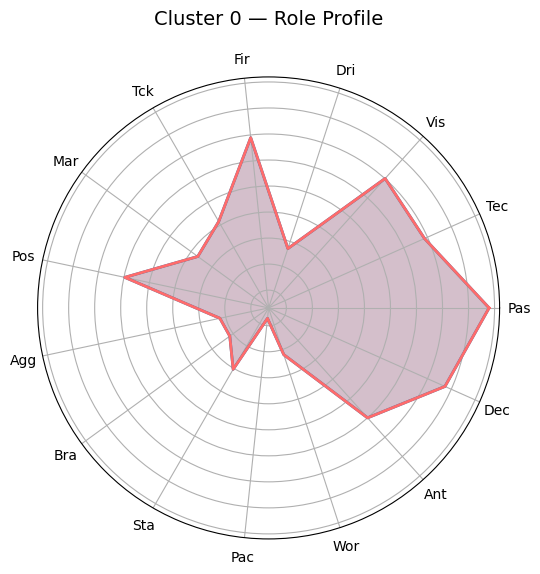

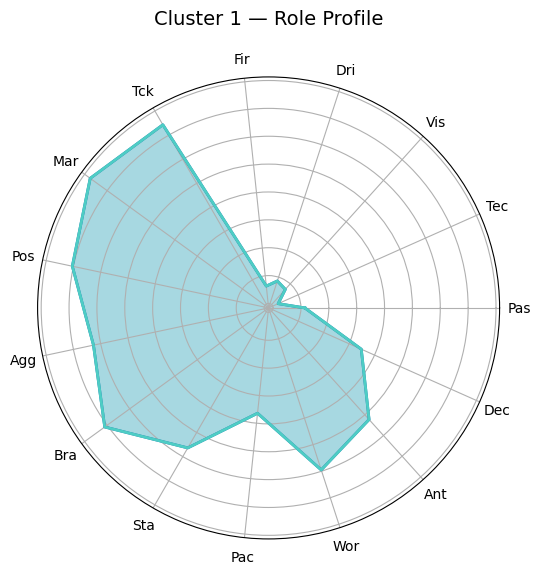

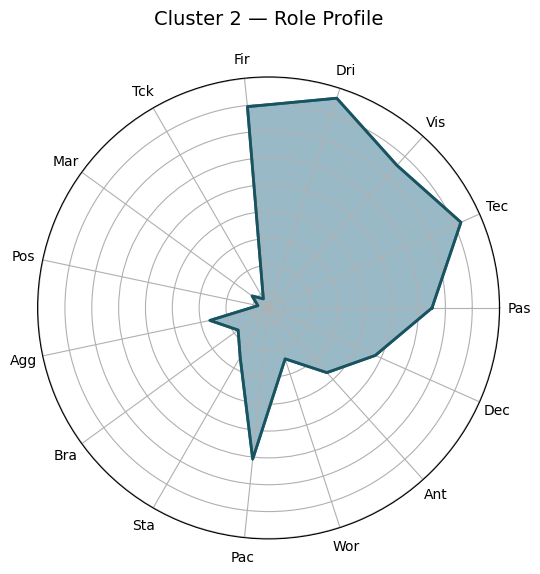

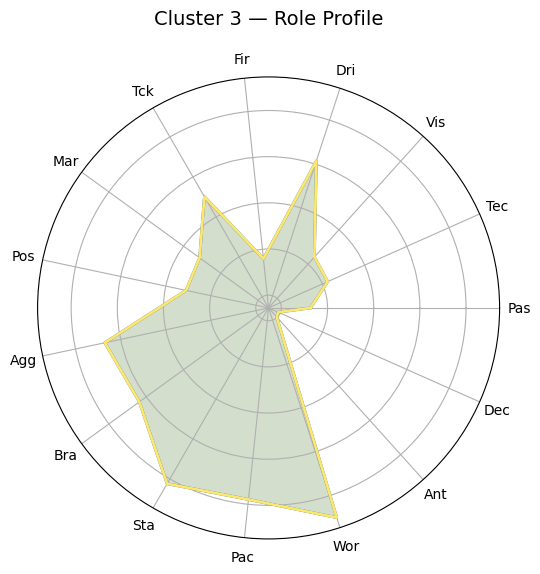

In [11]:
for c in cluster_means.index:
    plot_radar(cluster_means, radar_attrs, c)